## Import necessary library

In [1313]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from torch import nn
from torch.utils.data import DataLoader

## Get File path and load the csv data

In [1314]:
from util.data_path import soybean_price_avg as data_file

In [1315]:
wide = pd.read_csv(data_file)
long = wide.melt(id_vars="year", var_name="month", value_name="price").sort_values(
    ["year", "month"]
)

long["date"] = pd.to_datetime(
    (long["year"] - 543).astype(str)
    + "-"
    + long["month"].astype(str).str.zfill(2)
    + "-01"
)
long = long.set_index("date").sort_index()

## Set the training dataset and the predicted data

In [1316]:
gregorian_2566 = 2023
gregorian_2567 = 2024

train = long[long.index.year <= gregorian_2566]["price"].to_frame()
future = long[long.index.year == gregorian_2567]["price"].to_frame()

scaler = MinMaxScaler()
train["scaled"] = scaler.fit_transform(train[["price"]])

series = train["scaled"].values.astype(np.float32)

# LSTM Model And Predict Graph

## Create a sequence dataset class for LSTM prediction

In [1317]:
from util.lstm_cust_class import SeqDataset
from util.lstm_cust_class import LSTMRegressor

SEQ_LEN = 12
PRED_LEN = 12

In [1318]:
ds = SeqDataset(series, SEQ_LEN, PRED_LEN)
loader = DataLoader(ds, batch_size=len(ds))

## Training the LSTM model

In [1319]:
model = LSTMRegressor()
crit = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-2)

EPOCHS = 300
for epoch in range(1, EPOCHS + 1):
    for seq, targ in loader:
        opt.zero_grad()
        pred = model(seq)
        loss = crit(pred.squeeze(), targ[:, 0])
        loss.backward()
        opt.step()
    if epoch % 50 == 0:
        print(f"epoch {epoch:>3}/{EPOCHS}  loss={loss.item():.5f}")

epoch  50/300  loss=0.00663
epoch 100/300  loss=0.00428
epoch 150/300  loss=0.00404
epoch 200/300  loss=0.00379
epoch 250/300  loss=0.00380
epoch 300/300  loss=0.00312


## Predict the data for the next year

In [1320]:
model.eval()
with torch.no_grad():
    window = torch.from_numpy(series[-SEQ_LEN:]).unsqueeze(0).unsqueeze(-1)
    preds = []
    for _ in range(PRED_LEN):
        nxt = model(window)
        preds.append(nxt.item())
        window = torch.cat([window[:, 1:, :], nxt.unsqueeze(0)], dim=1)

preds = scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

gregorian_year = 2024
forecast = pd.Series(
    preds,
    index=pd.date_range(f"{gregorian_year}-01-01", periods=12, freq="MS"),
    name="forecast_price",
)

print("--- Forecast for 2567 ---")
print(forecast.round(2))

--- Forecast for 2567 ---
2024-01-01    16.10
2024-02-01    16.88
2024-03-01    17.54
2024-04-01    18.21
2024-05-01    18.57
2024-06-01    18.40
2024-07-01    18.27
2024-08-01    18.51
2024-09-01    18.72
2024-10-01    18.67
2024-11-01    18.48
2024-12-01    18.39
Freq: MS, Name: forecast_price, dtype: float64


In [1321]:
cmp = pd.concat([future["price"].rename("actual"), forecast], axis=1)
print("\n--- Actual vs Forecast (debug view) ---")
print(cmp.round(2))


--- Actual vs Forecast (debug view) ---
            actual  forecast_price
2024-01-01   19.45           16.10
2024-02-01   19.45           16.88
2024-03-01   19.45           17.54
2024-04-01   21.67           18.21
2024-05-01   19.78           18.57
2024-06-01   17.50           18.40
2024-07-01   17.38           18.27
2024-08-01   17.25           18.51
2024-09-01   17.13           18.72
2024-10-01   17.00           18.67
2024-11-01   17.00           18.48
2024-12-01   17.10           18.39


## Save the Forecasted Price LSTM Model

In [1322]:
import os
from datetime import datetime
from pathlib import Path

forecast_dir = Path("forecast_price")
forecast_dir = forecast_dir / "LSTM"
forecast_dir.mkdir(exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"{data_file.parent.name}_forecast.txt"
filepath = forecast_dir / filename

# Save forecast data to text file
with open(filepath, "w") as f:
    f.write(f"LSTM Forecast Results for Soybean Prices (2024) {timestamp}\n")
    f.write("=" * 50 + "\n\n")
    f.write("Forecast Data:\n")
    f.write("-" * 20 + "\n")
    for date, price in forecast.items():
        f.write(f"{date.strftime('%Y-%m-%d')}: {price:.2f}\n")

    f.write("\nOverall Statistics:\n")
    f.write("-" * 20 + "\n")
    f.write(f"Mean Forecast Price: {forecast.mean():.2f}\n")
    f.write(f"Min Forecast Price: {forecast.min():.2f}\n")
    f.write(f"Max Forecast Price: {forecast.max():.2f}\n")
    f.write(f"Standard Deviation: {forecast.std():.2f}\n")

print(f"Forecast prices saved to: {filepath}")
print(f"File size: {os.path.getsize(filepath)} bytes")

Forecast prices saved to: forecast_price\LSTM\soybean_forecast.txt
File size: 538 bytes


## Compare The Error of a predicted data in a table format

In [1323]:
error = cmp["actual"] - cmp["forecast_price"]
abs_error = abs(error)
# Calculate absolute percentage error
abs_pct_error = abs_error / cmp["actual"] * 100
mae_lstm = mean_absolute_error(cmp["actual"], cmp["forecast_price"])
mape_lstm = abs_pct_error.mean()  # Mean Absolute Percentage Error

print("\n--- Monthly Errors ---")
error_df = pd.DataFrame(
    {
        "actual": cmp["actual"],
        "forecast": cmp["forecast_price"],
        "error": error,
        "abs_error": abs_error,
        "abs_pct_error": abs_pct_error,  # Add percentage error to the dataframe
    }
)
print(error_df.round(4))
print(f"\nOverall Mean Absolute Error: {mae_lstm:.6f}")
print(f"Overall Mean Absolute Percentage Error: {mape_lstm:.4f}%")
print(f"LSTM Accuracy = {100 - (mae_lstm / cmp['actual'].mean() * 100):.2f}%")


--- Monthly Errors ---
            actual  forecast   error  abs_error  abs_pct_error
2024-01-01   19.45   16.0994  3.3506     3.3506        17.2268
2024-02-01   19.45   16.8833  2.5667     2.5667        13.1963
2024-03-01   19.45   17.5415  1.9085     1.9085         9.8121
2024-04-01   21.67   18.2146  3.4554     3.4554        15.9456
2024-05-01   19.78   18.5738  1.2062     1.2062         6.0982
2024-06-01   17.50   18.3994 -0.8994     0.8994         5.1394
2024-07-01   17.38   18.2671 -0.8871     0.8871         5.1039
2024-08-01   17.25   18.5120 -1.2620     1.2620         7.3159
2024-09-01   17.13   18.7183 -1.5883     1.5883         9.2718
2024-10-01   17.00   18.6664 -1.6664     1.6664         9.8023
2024-11-01   17.00   18.4813 -1.4813     1.4813         8.7138
2024-12-01   17.10   18.3906 -1.2906     1.2906         7.5474

Overall Mean Absolute Error: 1.796872
Overall Mean Absolute Percentage Error: 9.5978%
LSTM Accuracy = 90.21%


## Plot The predicted data compare to an actual data

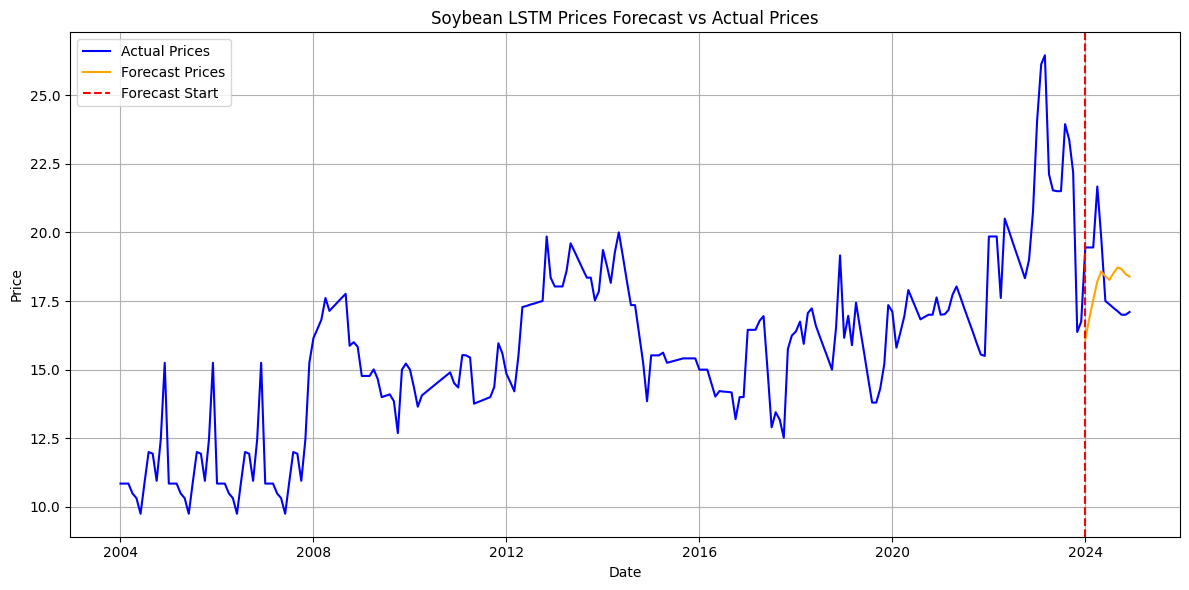

In [1324]:
plt.figure(figsize=(12, 6))
plt.plot(long.index, long["price"], label="Actual Prices", color="blue")
plt.plot(forecast.index, forecast, label="Forecast Prices", color="orange")
plt.axvline(
    x=pd.Timestamp(f"{gregorian_year}-01-01"),
    color="red",
    linestyle="--",
    label="Forecast Start",
)
plt.title(f"{data_file.parent.name.capitalize()} LSTM Prices Forecast vs Actual Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Transformer Model And Error Graph

## PLot the Error Analysis graph

<Figure size 1400x800 with 0 Axes>

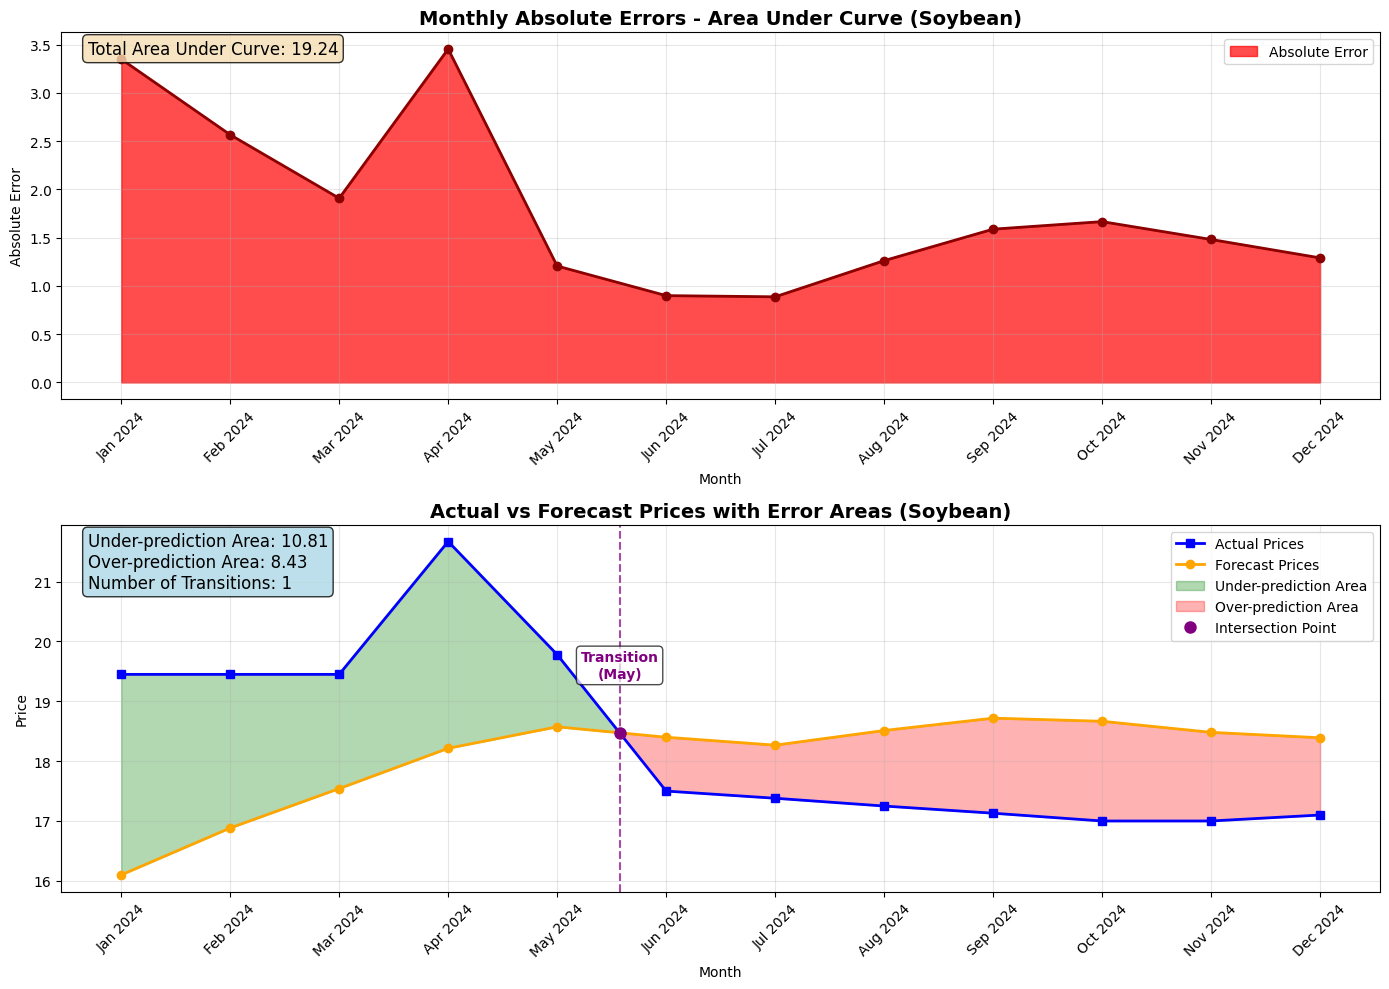

In [1325]:
# Create area plot to visualize monthly errors
plt.figure(figsize=(14, 8))

# Calculate error values (in case this cell is run before the error calculation cell)
error = cmp["actual"] - cmp["forecast_price"]
abs_error = abs(error)

# Add the error columns to the cmp DataFrame if they don't exist
if "error" not in cmp.columns:
    cmp["error"] = error
if "abs_error" not in cmp.columns:
    cmp["abs_error"] = abs_error

# Create month labels for better readability
month_labels = [date.strftime("%b %Y") for date in cmp.index]

# Create subplots for different error visualizations
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Area plot of absolute errors
ax1.fill_between(
    range(len(cmp)), cmp["abs_error"], alpha=0.7, color="red", label="Absolute Error"
)
ax1.plot(range(len(cmp)), cmp["abs_error"], color="darkred", linewidth=2, marker="o")
ax1.set_title(
    f"Monthly Absolute Errors - Area Under Curve ({data_file.parent.name.capitalize()})",
    fontsize=14,
    fontweight="bold",
)
ax1.set_xlabel("Month")
ax1.set_ylabel("Absolute Error")
ax1.set_xticks(range(len(cmp)))
ax1.set_xticklabels(month_labels, rotation=45)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Add area calculation text
total_area = np.trapezoid(cmp["abs_error"])
ax1.text(
    0.02,
    0.98,
    f"Total Area Under Curve: {total_area:.2f}",
    transform=ax1.transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

# Plot 2: Comparison of actual vs forecast with error areas
ax2.plot(
    range(len(cmp)),
    cmp["actual"],
    label="Actual Prices",
    color="blue",
    linewidth=2,
    marker="s",
)
ax2.plot(
    range(len(cmp)),
    cmp["forecast_price"],
    label="Forecast Prices",
    color="orange",
    linewidth=2,
    marker="o",
)

# Find intersection points between actual and forecast
intersect_indices = []
for i in range(1, len(cmp)):
    # Check if actual and forecast cross between i-1 and i
    prev_diff = cmp["actual"].iloc[i - 1] - cmp["forecast_price"].iloc[i - 1]
    curr_diff = cmp["actual"].iloc[i] - cmp["forecast_price"].iloc[i]

    if (prev_diff * curr_diff <= 0) and (
        prev_diff != 0 or curr_diff != 0
    ):  # Sign change or one is zero
        # Linear interpolation to find exact intersection point
        if prev_diff == curr_diff:  # They're equal (both 0)
            t = 0  # At point i-1
        else:
            t = abs(prev_diff) / (abs(prev_diff) + abs(curr_diff))

        intersect_x = (i - 1) + t
        intersect_y = cmp["actual"].iloc[i - 1] + t * (
            cmp["actual"].iloc[i] - cmp["actual"].iloc[i - 1]
        )

        intersect_indices.append((intersect_x, intersect_y))

# Fill areas between actual and forecast to show errors
ax2.fill_between(
    range(len(cmp)),
    cmp["actual"],
    cmp["forecast_price"],
    where=(cmp["actual"] >= cmp["forecast_price"]),
    color="green",
    alpha=0.3,
    label="Under-prediction Area",
    interpolate=True,
)
ax2.fill_between(
    range(len(cmp)),
    cmp["actual"],
    cmp["forecast_price"],
    where=(cmp["actual"] < cmp["forecast_price"]),
    color="red",
    alpha=0.3,
    label="Over-prediction Area",
    interpolate=True,
)

# Mark intersection points with vertical lines and markers
for idx, (x, y) in enumerate(intersect_indices):
    ax2.axvline(x, color="purple", linestyle="--", alpha=0.7, linewidth=1.5)
    ax2.plot(
        x,
        y,
        "o",
        color="purple",
        markersize=8,
        label="Intersection Point" if idx == 0 else "",
    )
    ax2.text(
        x,
        y * 1.05,
        f"Transition\n({month_labels[int(x)][:3]})",
        ha="center",
        color="purple",
        fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.3"),
    )

ax2.set_title(
    f"Actual vs Forecast Prices with Error Areas ({data_file.parent.name.capitalize()})",
    fontsize=14,
    fontweight="bold",
)
ax2.set_xlabel("Month")
ax2.set_ylabel("Price")
ax2.set_xticks(range(len(cmp)))
ax2.set_xticklabels(month_labels, rotation=45)
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right")

# Calculate and display area statistics
under_pred_area = np.trapezoid(np.maximum(cmp["actual"] - cmp["forecast_price"], 0))
over_pred_area = np.trapezoid(np.maximum(cmp["forecast_price"] - cmp["actual"], 0))

# Count number of transitions
num_transitions = len(intersect_indices)

# Create statistics text
stats_text = (
    f"Under-prediction Area: {under_pred_area:.2f}\n"
    f"Over-prediction Area: {over_pred_area:.2f}\n"
    f"Number of Transitions: {num_transitions}"
)

ax2.text(
    0.02,
    0.98,
    stats_text,
    transform=ax2.transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8),
)

plt.tight_layout()
plt.show()

## Analyze The Error of a predicted data

In [1326]:
print("\n--- Area Under Curve Analysis ---")
print(f"Total Absolute Error Area: {total_area:.4f}")
print(f"Under-prediction Area: {under_pred_area:.4f}")
print(f"Over-prediction Area: {over_pred_area:.4f}")
print(f"Net Error Area: {under_pred_area - over_pred_area:.4f}")
print(f"Average Monthly Absolute Error: {total_area / len(cmp):.4f}")
print(f"Number of Transition Points: {len(intersect_indices)}")

# Monthly breakdown
print("\n--- Monthly Error Areas ---")
for i, (date, row) in enumerate(cmp.iterrows()):
    month_label = date.strftime("%b %Y")
    error_type = (
        "Under-prediction"
        if row["actual"] > row["forecast_price"]
        else "Over-prediction"
        if row["actual"] < row["forecast_price"]
        else "Exact Match"
    )
    print(f"{month_label}: Abs Error = {row['abs_error']:.4f} ({error_type})")

# Transition analysis
if intersect_indices:
    print("\n--- Transition Points ---")
    for idx, (x, y) in enumerate(intersect_indices):
        transition_month = month_labels[int(x)]
        next_month = month_labels[min(int(x) + 1, len(month_labels) - 1)]
        print(
            f"Transition {idx + 1}: Between {transition_month} and {next_month} at position {x:.2f}"
        )

        # Determine transition type
        i = int(x)
        if i + 1 < len(cmp):
            before_error = cmp["actual"].iloc[i] - cmp["forecast_price"].iloc[i]
            after_error = cmp["actual"].iloc[i + 1] - cmp["forecast_price"].iloc[i + 1]
            direction = (
                "Under to Over"
                if before_error > 0 and after_error < 0
                else "Over to Under"
            )
            print(f"   Direction: {direction} prediction")
else:
    print("\n--- No Transition Points Found ---")
    print(
        "The model consistently either under-predicts or over-predicts throughout the entire period."
    )


--- Area Under Curve Analysis ---
Total Absolute Error Area: 19.2418
Under-prediction Area: 10.8121
Over-prediction Area: 8.4298
Net Error Area: 2.3823
Average Monthly Absolute Error: 1.6035
Number of Transition Points: 1

--- Monthly Error Areas ---
Jan 2024: Abs Error = 3.3506 (Under-prediction)
Feb 2024: Abs Error = 2.5667 (Under-prediction)
Mar 2024: Abs Error = 1.9085 (Under-prediction)
Apr 2024: Abs Error = 3.4554 (Under-prediction)
May 2024: Abs Error = 1.2062 (Under-prediction)
Jun 2024: Abs Error = 0.8994 (Over-prediction)
Jul 2024: Abs Error = 0.8871 (Over-prediction)
Aug 2024: Abs Error = 1.2620 (Over-prediction)
Sep 2024: Abs Error = 1.5883 (Over-prediction)
Oct 2024: Abs Error = 1.6664 (Over-prediction)
Nov 2024: Abs Error = 1.4813 (Over-prediction)
Dec 2024: Abs Error = 1.2906 (Over-prediction)

--- Transition Points ---
Transition 1: Between May 2024 and Jun 2024 at position 4.57
   Direction: Under to Over prediction


## Save the model Error Analysis to a file 

In [1327]:
error_record_dir = Path("error_record") / "LSTM"
error_record_dir.mkdir(exist_ok=True, parents=True)

crop_name = data_file.parent.name
filename = f"{crop_name}_error_metrics.txt"
filepath = error_record_dir / filename

In [1328]:
mae_value = mae_lstm
mape_value = mape_lstm
accuracy = 100 - (mae_lstm / cmp["actual"].mean() * 100)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save metrics to text file
with open(filepath, "w") as f:
    f.write(
        f"LSTM Model Evaluation Metrics for {crop_name.capitalize()} - {timestamp}\n"
    )
    f.write("=" * 60 + "\n\n")

    f.write("Overall Metrics:\n")
    f.write("-" * 20 + "\n")
    f.write(f"Mean Absolute Error (MAE): {mae_value:.6f}\n")
    f.write(f"Mean Absolute Percentage Error (MAPE): {mape_value:.4f}%\n")
    f.write(f"Model Accuracy: {accuracy:.2f}%\n\n")

    f.write("Monthly Evaluation:\n")
    f.write("-" * 20 + "\n")
    f.write(
        f"{'Month':<10} {'Actual':<10} {'Forecast':<10} {'Error':<10} {'Abs Error':<10} {'% Error':<10}\n"
    )

    for date, row in error_df.iterrows():
        month_label = date.strftime("%b %Y")
        f.write(
            f"{month_label:<10} {row['actual']:<10.2f} {row['forecast']:<10.2f} {row['error']:<10.4f} {row['abs_error']:<10.4f} {row['abs_pct_error']:<10.2f}%\n"
        )

    f.write("\nArea Under Curve Analysis:\n")
    f.write("-" * 20 + "\n")
    f.write(f"Total Absolute Error Area: {total_area:.4f}\n")
    f.write(f"Under-prediction Area: {under_pred_area:.4f}\n")
    f.write(f"Over-prediction Area: {over_pred_area:.4f}\n")
    f.write(f"Net Error Area: {under_pred_area - over_pred_area:.4f}\n")
    f.write(f"Average Monthly Absolute Error: {total_area / len(cmp):.4f}\n")
    f.write(f"Number of Transition Points: {len(intersect_indices)}\n")

    # Add transition information
    if intersect_indices:
        f.write("\nTransition Points:\n")
        f.write("-" * 20 + "\n")
        for idx, (x, y) in enumerate(intersect_indices):
            transition_month = month_labels[int(x)]
            next_month = month_labels[min(int(x) + 1, len(month_labels) - 1)]
            f.write(
                f"Transition {idx + 1}: Between {transition_month} and {next_month} at position {x:.2f}\n"
            )

            # Determine transition type
            i = int(x)
            if i + 1 < len(cmp):
                before_error = cmp["actual"].iloc[i] - cmp["forecast_price"].iloc[i]
                after_error = (
                    cmp["actual"].iloc[i + 1] - cmp["forecast_price"].iloc[i + 1]
                )
                direction = (
                    "Under to Over"
                    if before_error > 0 and after_error < 0
                    else "Over to Under"
                )
                f.write(f"   Direction: {direction} prediction\n")

print(f"Evaluation metrics saved to: {filepath}")
print(f"File size: {os.path.getsize(filepath)} bytes")

Evaluation metrics saved to: error_record\LSTM\soybean_error_metrics.txt
File size: 1594 bytes
